<h1 style="text-align: center;">Wine Clustering Analysis</h1>

## Project Purpose

The aim of this project is to explore **unsupervised machine learning** by grouping wine samples into meaningful clusters based on their numerical characteristics.

This notebook will focus on understanding the clustering workflow, including data inspection, preprocessing, cluster selection, model evaluation, and interpretation of the resulting groups.


-------------------
## Data Import

In [16]:
import pandas as pd
import numpy as np

In [5]:
data = pd.read_csv("wine-clustering.csv")

----------------
## EDA (Exploratory Data Analysis)

This section will perform an initial statistical inspection of the wine dataset to understand its structure, data types, missing values, duplicates, feature ranges, and overall distribution before moving to visualization and clustering.


In [6]:
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
data.shape

(178, 13)

In [8]:
data.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [18]:
data.nunique()

Alcohol                 126
Malic_Acid              133
Ash                      79
Ash_Alcanity             63
Magnesium                53
Total_Phenols            97
Flavanoids              132
Nonflavanoid_Phenols     39
Proanthocyanins         101
Color_Intensity         132
Hue                      78
OD280                   122
Proline                 121
dtype: int64

In [20]:
data.duplicated().sum()

np.int64(0)

### Initial Statistical EDA Evaluation

The dataset contains **178 rows and 13 numerical features**, with no missing values or duplicate records. The features have noticeably different numerical ranges, indicating that scaling will be necessary before applying distance-based clustering methods such as K-Means.

The descriptive statistics also suggest a few possible outliers in features such as `Ash_Alcanity`, `Color_Intensity`, and `Proline`. These values are not necessarily problematic, but they should be examined further through visualization before preprocessing decisions are made.

Overall, the dataset appears clean and suitable for clustering, with scaling and outlier inspection being the main considerations before modelling.


-------------
## Exploratory Data Analysis Using Visualization

This section will visually examine the distribution, spread, outliers, and relationships among the numerical features. Histograms and box plots will be used to inspect individual features, while a correlation heatmap and selected scatter plots will help identify relationships and possible grouping patterns that may be relevant for clustering.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

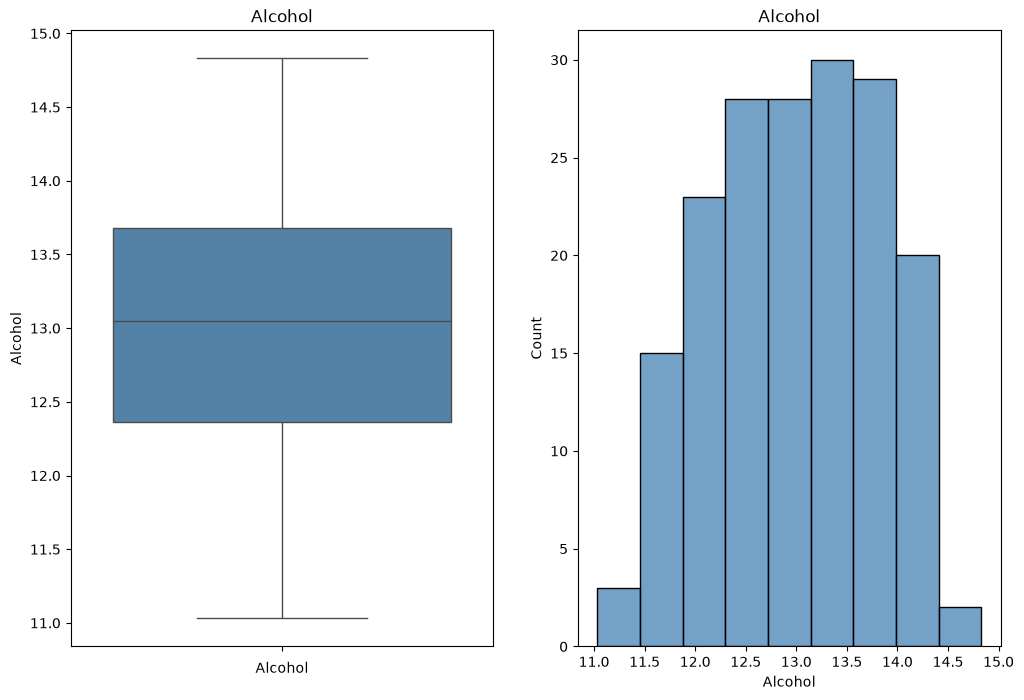

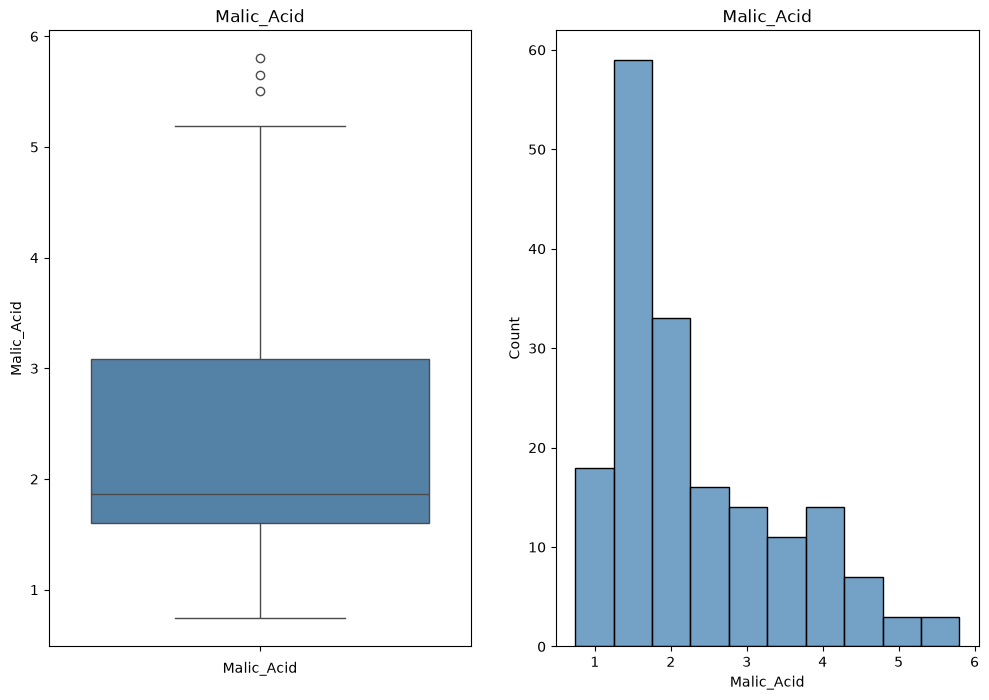

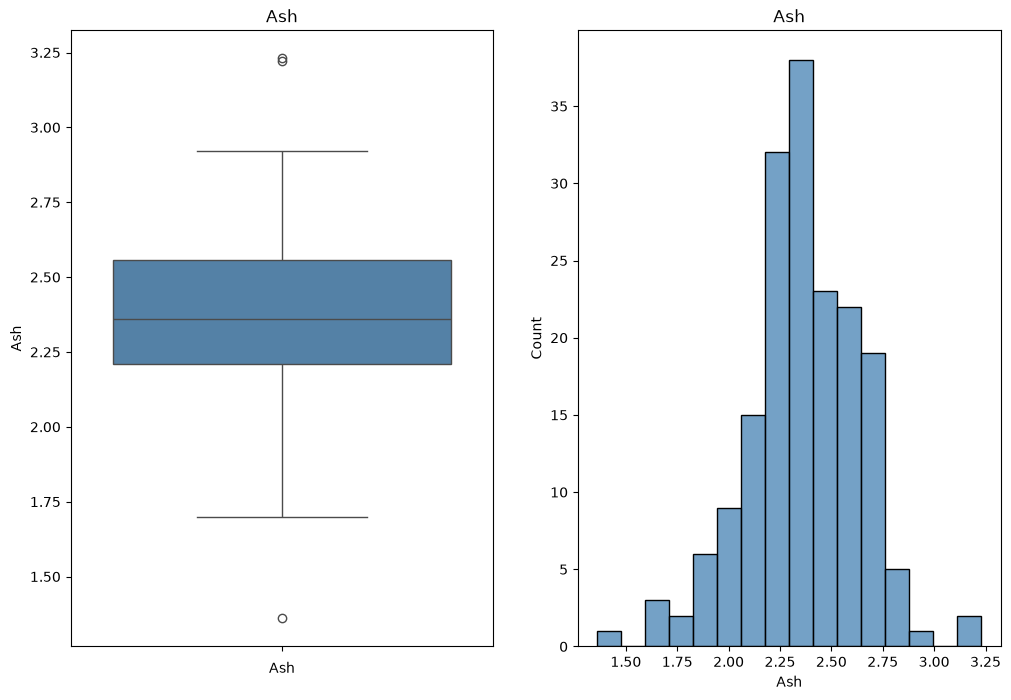

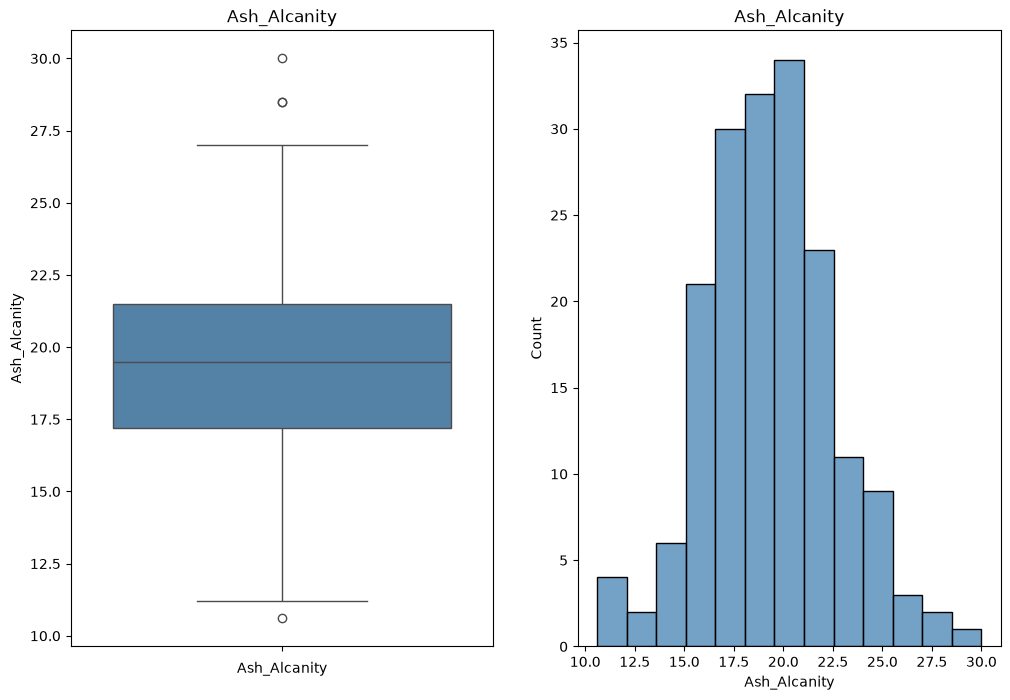

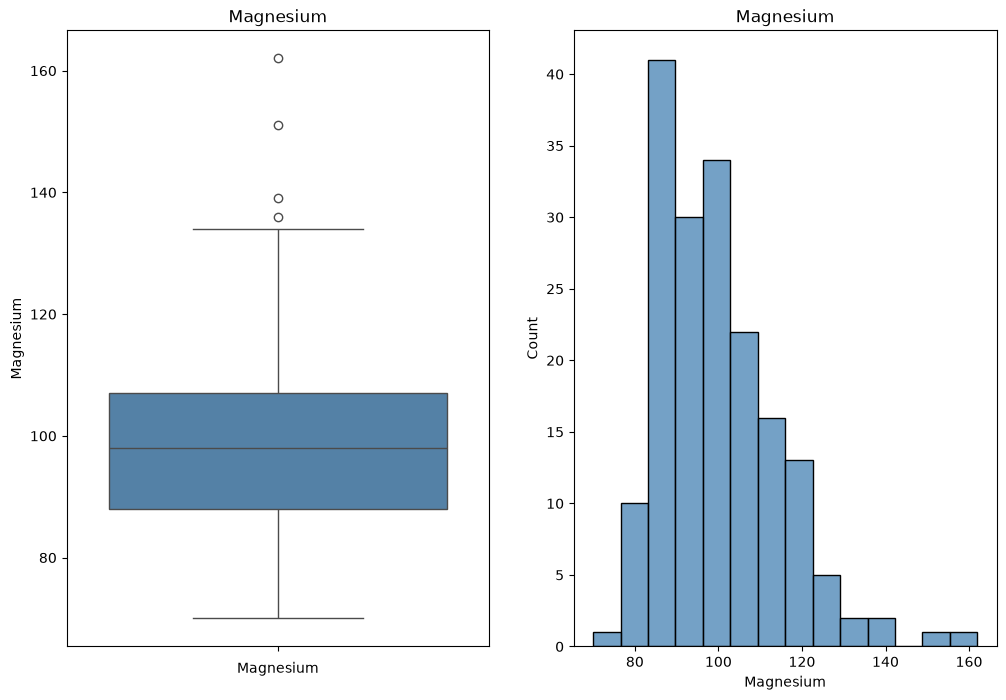

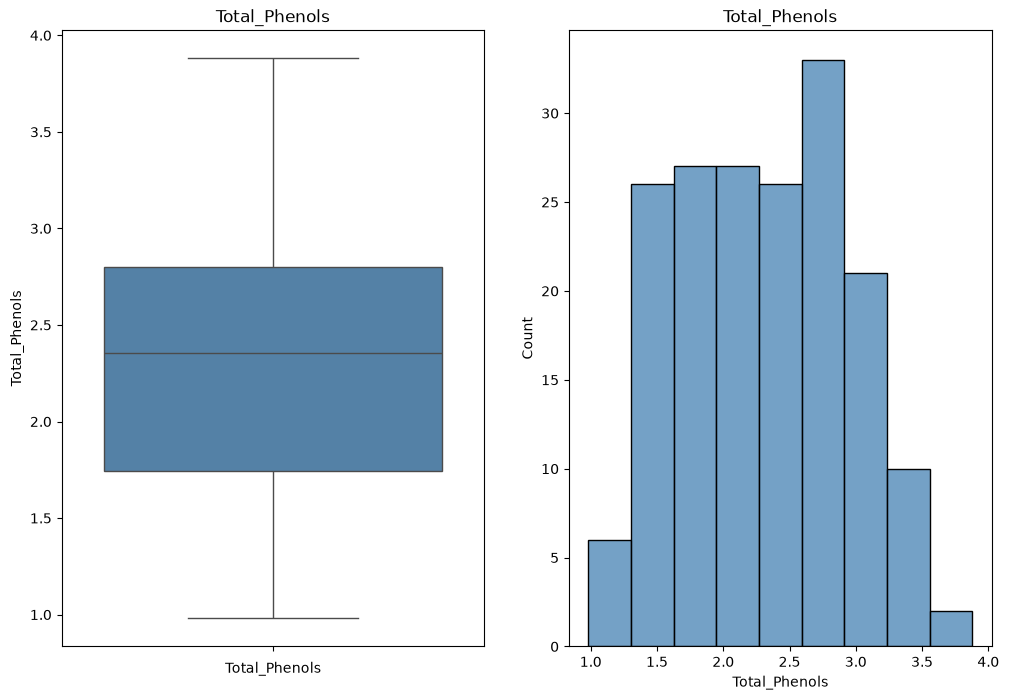

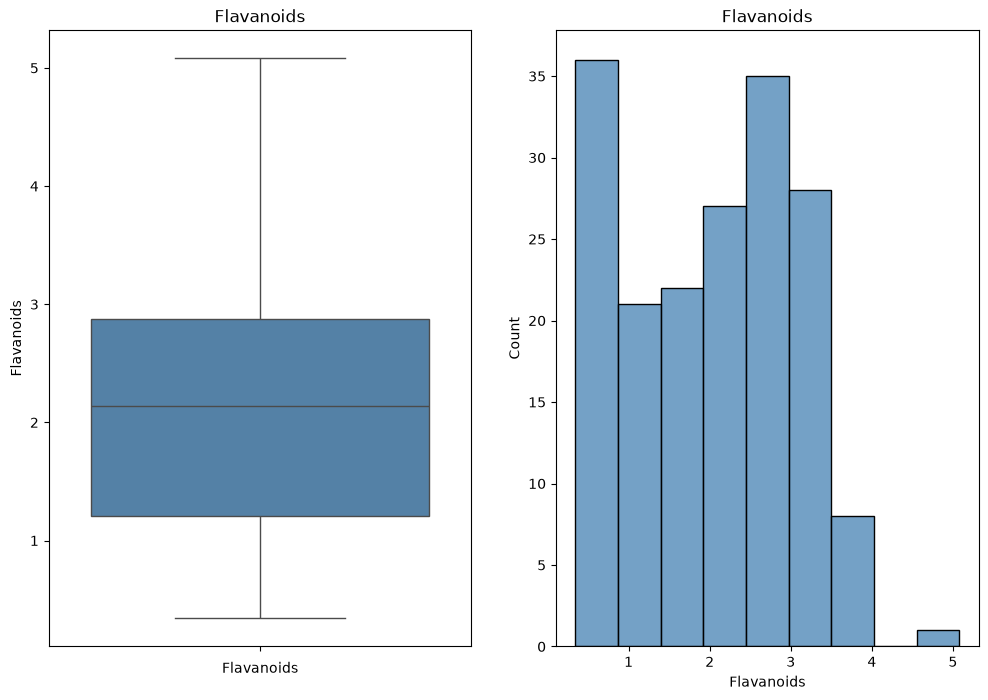

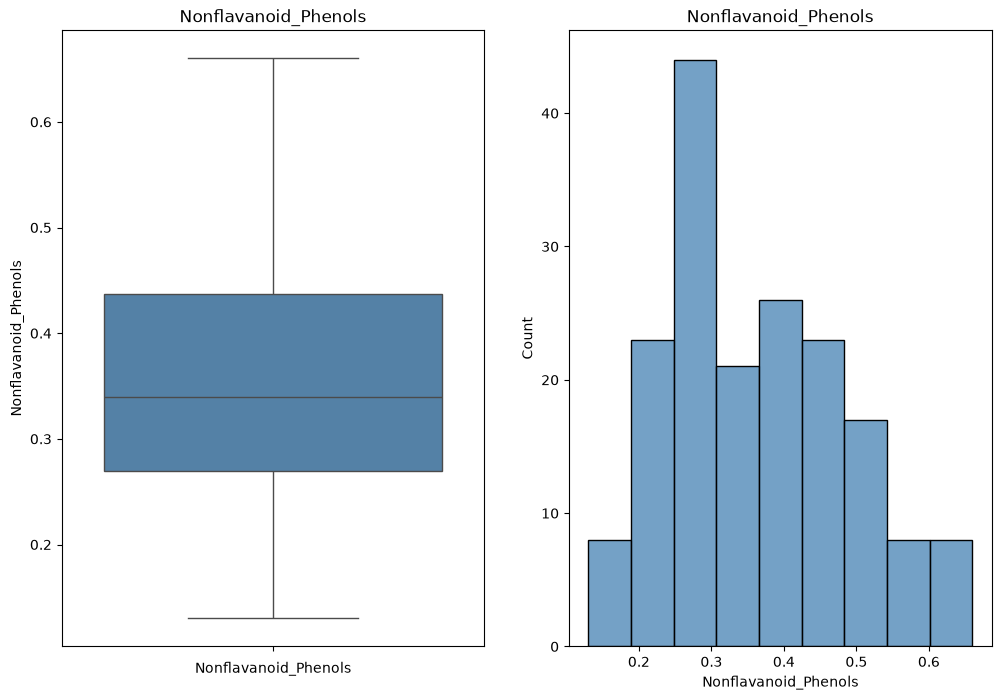

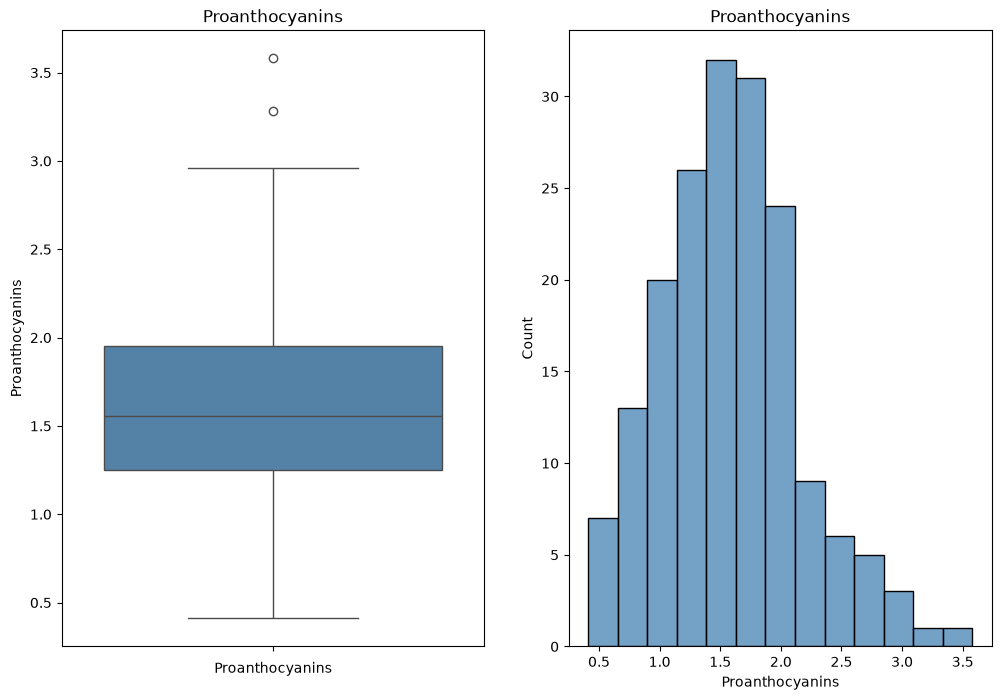

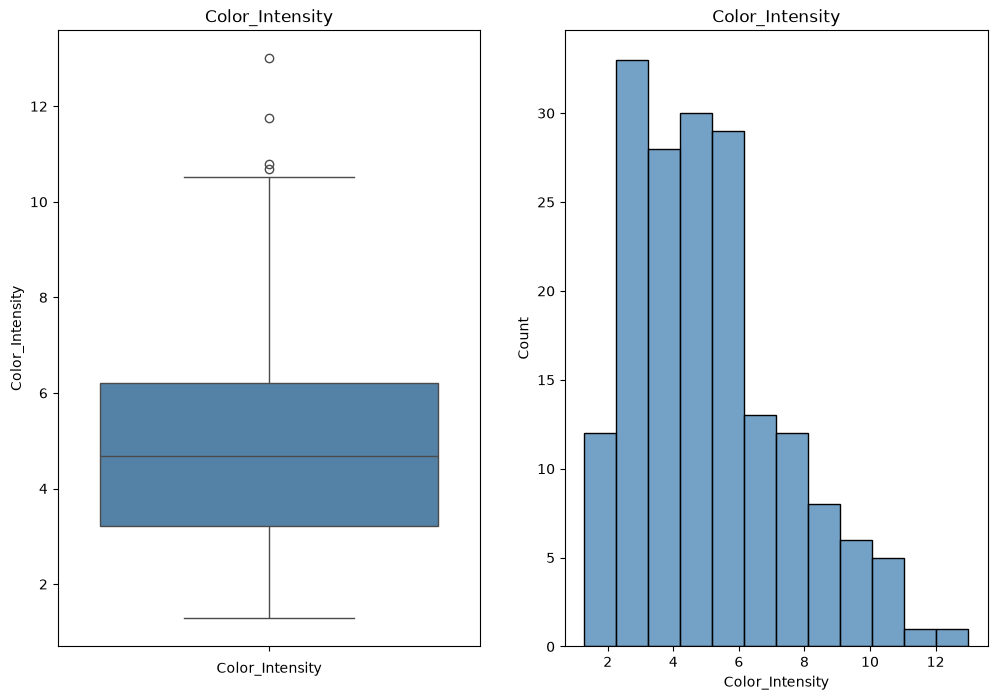

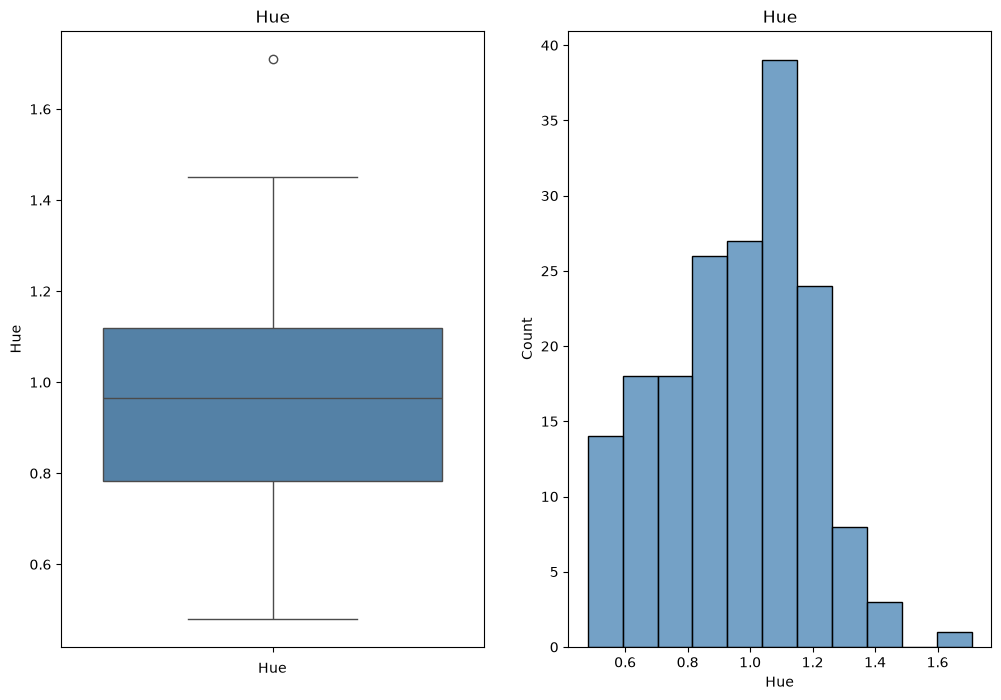

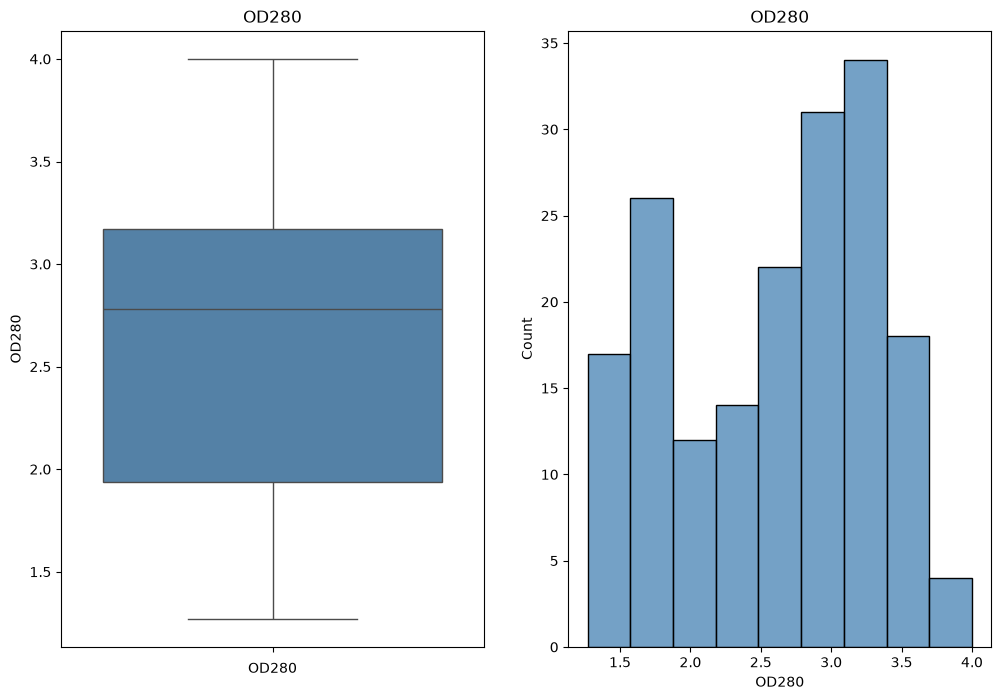

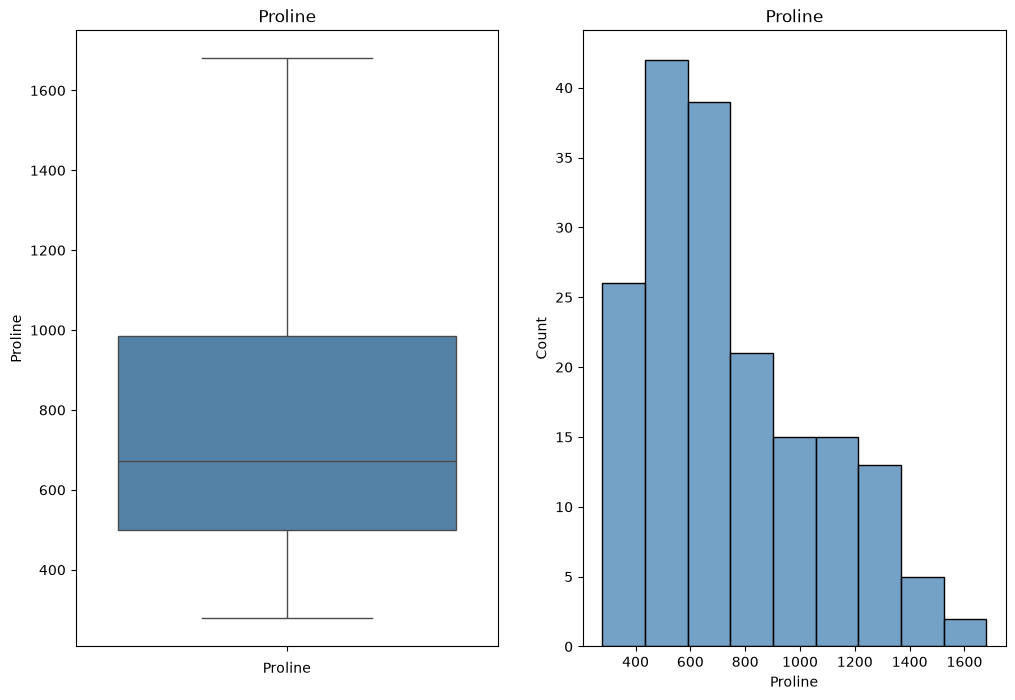

In [25]:
for column in data.columns.to_list():
    fig = plt.figure(figsize=(12,8))
    ax0 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,2)

    sns.boxplot(data=data, y=column, color="steelblue", ax=ax0)
    ax0.set_title(column)
    ax0.set_xlabel(column)

    sns.histplot(data=data, x=column, color="steelblue", ax=ax1)
    ax1.set_title(column)
    ax1.set_xlabel(column)

    plt.show()


### Visualization Evaluation

#### Clean distributions with no obvious outliers
- Alcohol
- Total_Phenols
- Nonflavanoid_Phenols

#### Mostly balanced distributions with a few outliers
- Ash
- Ash_Alcanity
- Hue

#### Right-skewed distributions with upper-end outliers
- Malic_Acid
- Magnesium
- Proanthocyanins
- Color_Intensity

#### Right-skewed distribution with no obvious outliers
- Proline

#### Irregular / non-normal distributions
- Flavanoids
- OD280

### Overall Observation

The features show different patterns of skewness, outlier presence, and numerical scale. These differences should be considered when selecting an appropriate scaling method before clustering.

------------------------------------------------
## Correlation Analysis

This section will examine the relationships between the numerical features using a **correlation heatmap**. The aim is to identify features that have strong positive or negative relationships and to understand which variables tend to change together.

This analysis can also help identify highly correlated features that may contain similar or overlapping information before moving toward clustering.


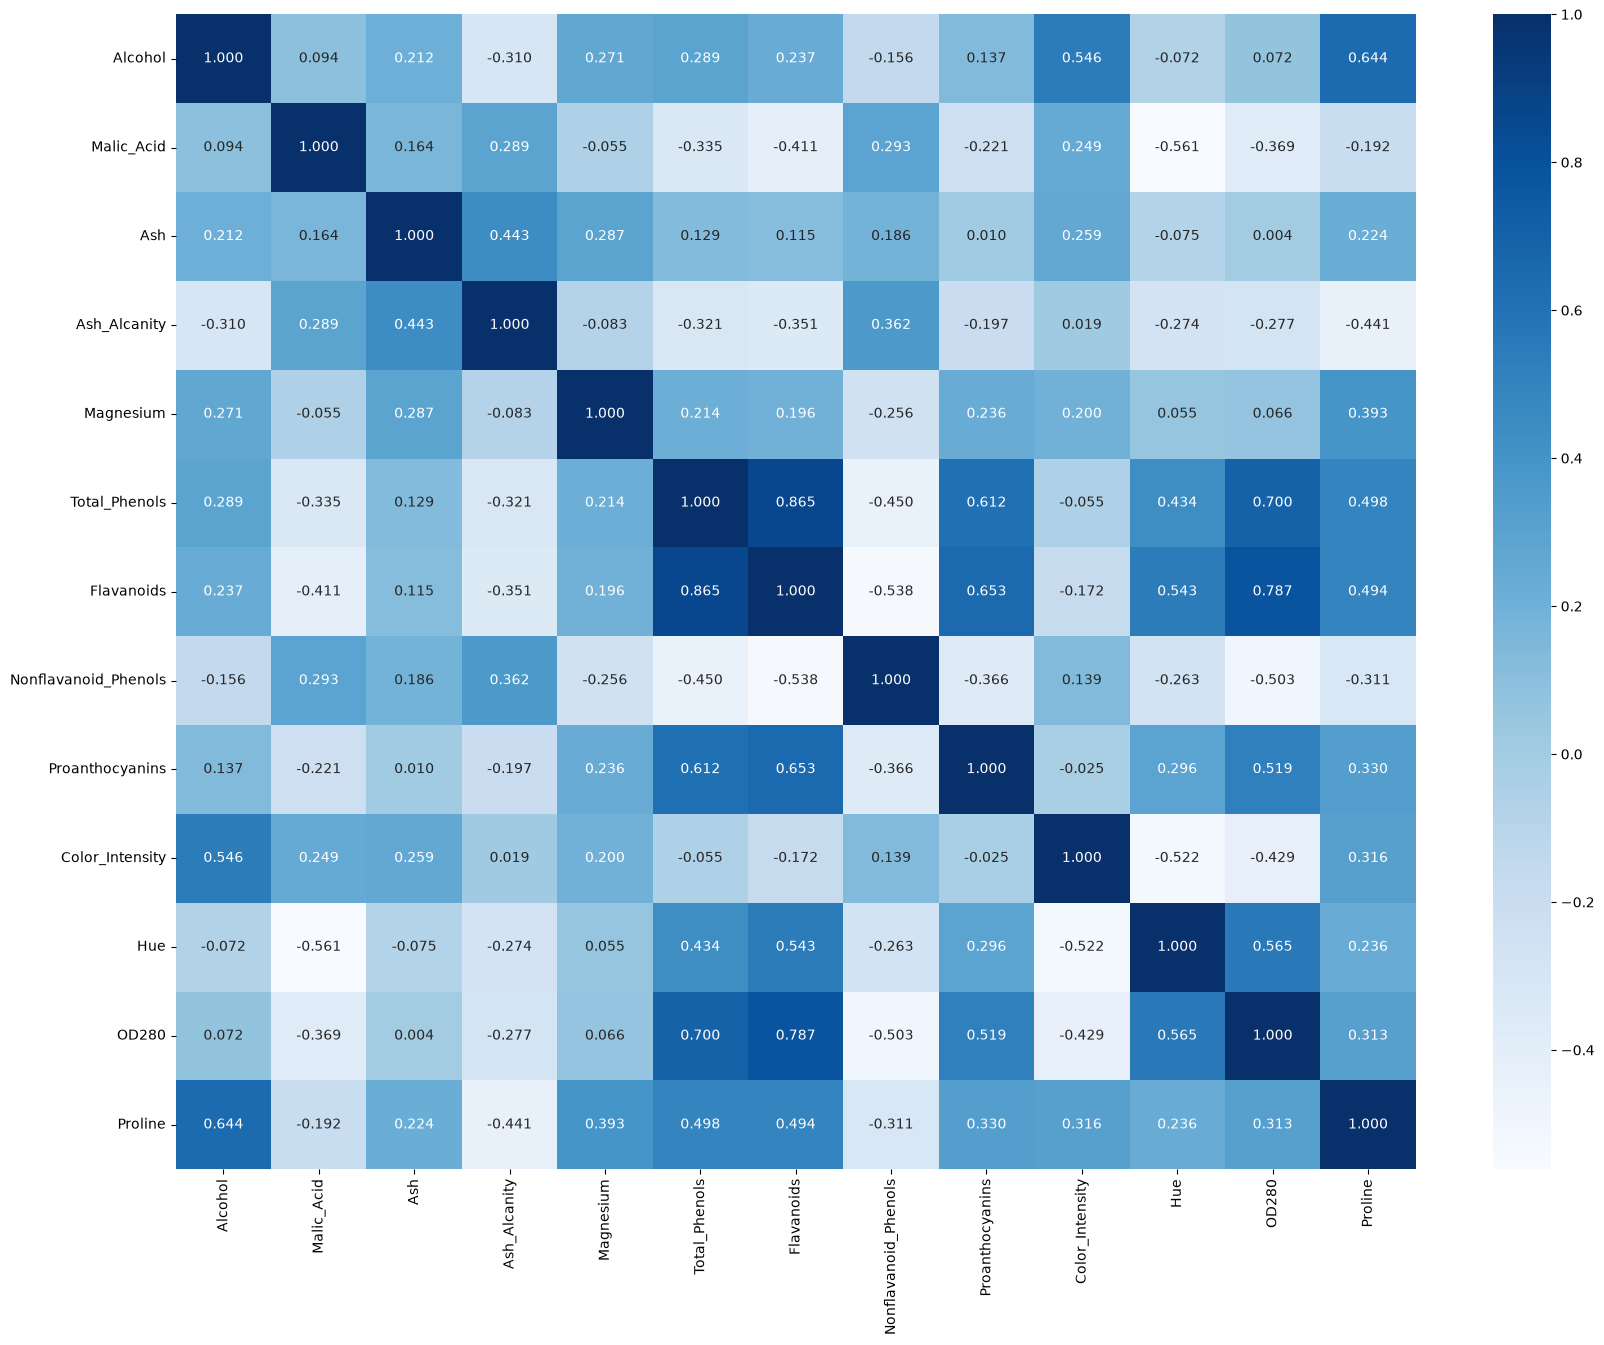

In [27]:
plt.figure(figsize=(20,15))
sns.heatmap(data=data.corr(), annot=True, fmt=".3f", cmap="Blues")
plt.show()

### Correlation Evaluation

Most features do not show extremely high correlation, suggesting that they retain distinct information. The strongest relationship is between Total_Phenols and Flavanoids, with a few other moderate relationships also present.

Overall, there are no near-duplicate features based on correlation alone.

-----------------
## K-Means Clustering — Experiment 1

This will be the first clustering experiment on the wine dataset. To establish a simple baseline, **StandardScaler will be applied to all numerical features** so that differences in feature magnitude do not dominate the distance calculations used by K-Means.

The initial K-Means results will then be evaluated to understand how well the data forms clusters under this basic preprocessing approach. Based on the results, further decisions can be made regarding whether different scaling methods, transformations, or other preprocessing adjustments are necessary.


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [30]:
data_exp1 = data.copy()

In [38]:
scaler = StandardScaler()
data_exp1 = scaler.fit_transform(data_exp1)
data_exp1 = pd.DataFrame(data_exp1, columns=data.columns)

In [41]:
interias = []
labels = []
centers = []

In [42]:
for n in range(2,9):
    model = KMeans(n_clusters=n, init="k-means++", n_init="auto", max_iter=300, tol=1e-4, random_state=1,algorithm="lloyd")
    model.fit(data_exp1)
    interias.append(model.inertia_)
    labels.append(model.labels_)
    centers.append(model.cluster_centers_)

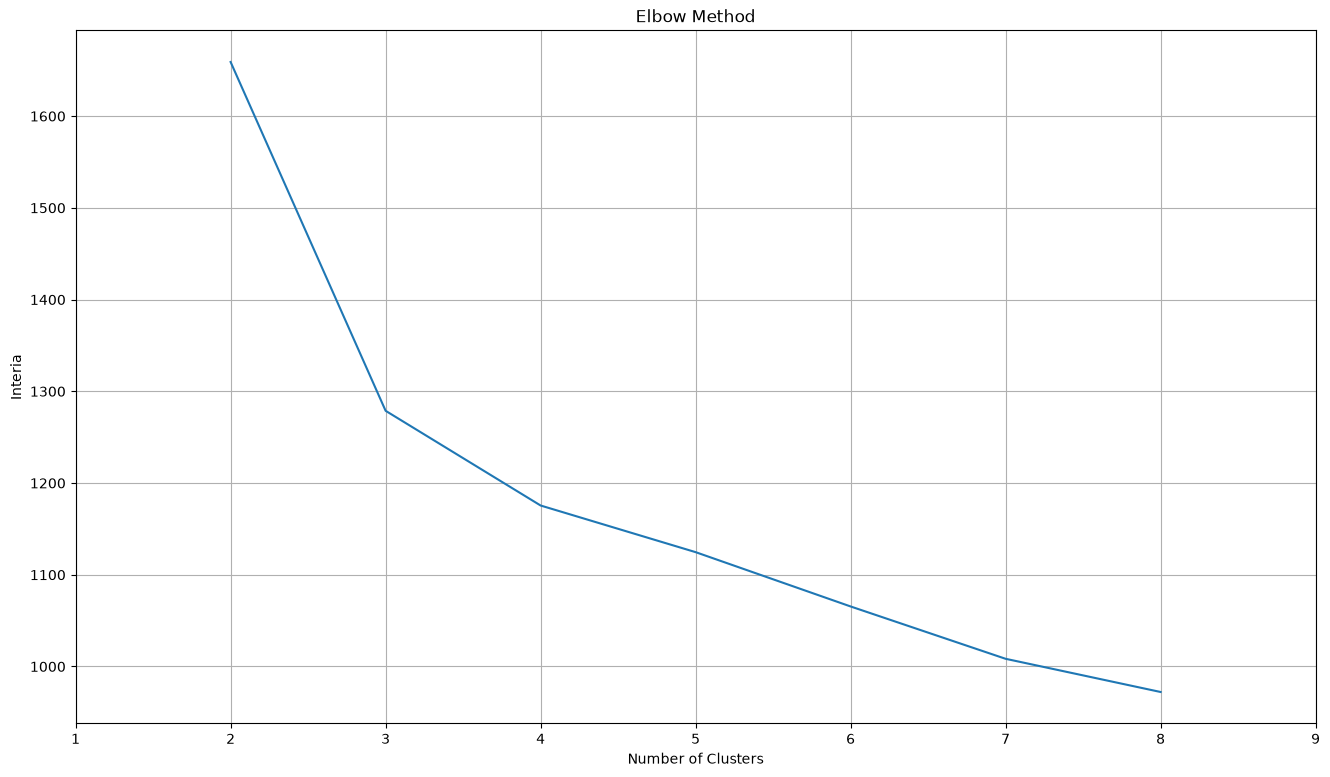

In [54]:
plt.figure(figsize=(16,9))
plt.plot(range(2,9), interias)
plt.xlim(1,9)
plt.xlabel("Number of Clusters")
plt.ylabel("Interia")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [56]:
silhouette_scores = []
for i in range(len(labels)):
    score = silhouette_score(data_exp1, labels[i])
    silhouette_scores.append(score)

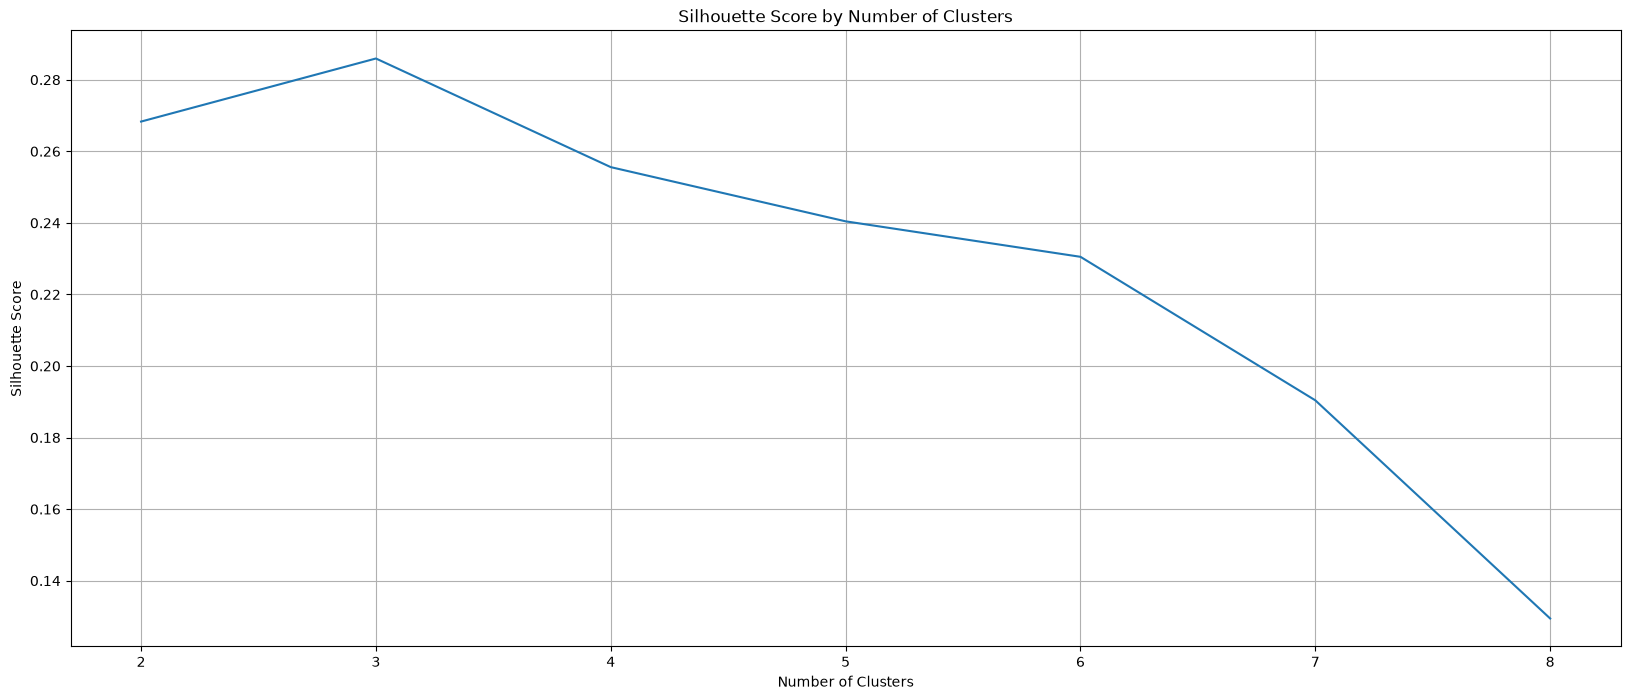

In [61]:
plt.figure(figsize=(20,8))
plt.plot(range(2,9), silhouette_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.grid()
plt.show()

### Cluster Count Evaluation

The Elbow Method indicated that the most reasonable number of clusters lies around **3 to 4**, while the Silhouette Score reached its highest value at **3 clusters**. Based on both methods, **`k = 3`** was selected as the best choice for the first K-Means experiment.


-----------
## Final K-Means Model — Experiment 1

Based on the Elbow Method and Silhouette Score, **3 clusters** were selected as the most suitable choice for this experiment. A final K-Means model will now be trained using `k = 3` on the standardized dataset.

After fitting the model, the resulting cluster assignments, cluster sizes, and centroid values will be examined to better understand how the observations have been grouped.


In [62]:
model = KMeans(n_clusters=3, init="k-means++", n_init="auto", max_iter=300, tol=1e-4, random_state=1,algorithm="lloyd")

In [63]:
model.fit(data_exp1)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",1
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 13)","[

In [69]:
cluster_sample_size = np.bincount(model.labels_)
cluster_sample_size

array([66, 51, 61])

In [70]:
centers_df = pd.DataFrame(model.cluster_centers_, columns=data.columns)
centers_df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,-0.939003,-0.391966,-0.439201,0.208988,-0.463774,-0.053348,0.066904,-0.019822,0.064792,-0.882075,0.452982,0.289738,-0.756026
1,0.164907,0.871547,0.186898,0.524367,-0.075473,-0.979330,-1.215248,0.726064,-0.779706,0.941539,-1.164789,-1.292412,-0.407088
2,0.878097,-0.304576,0.318942,-0.664524,0.564888,0.876505,0.943639,-0.585590,0.581783,0.167188,0.483728,0.767053,1.158347


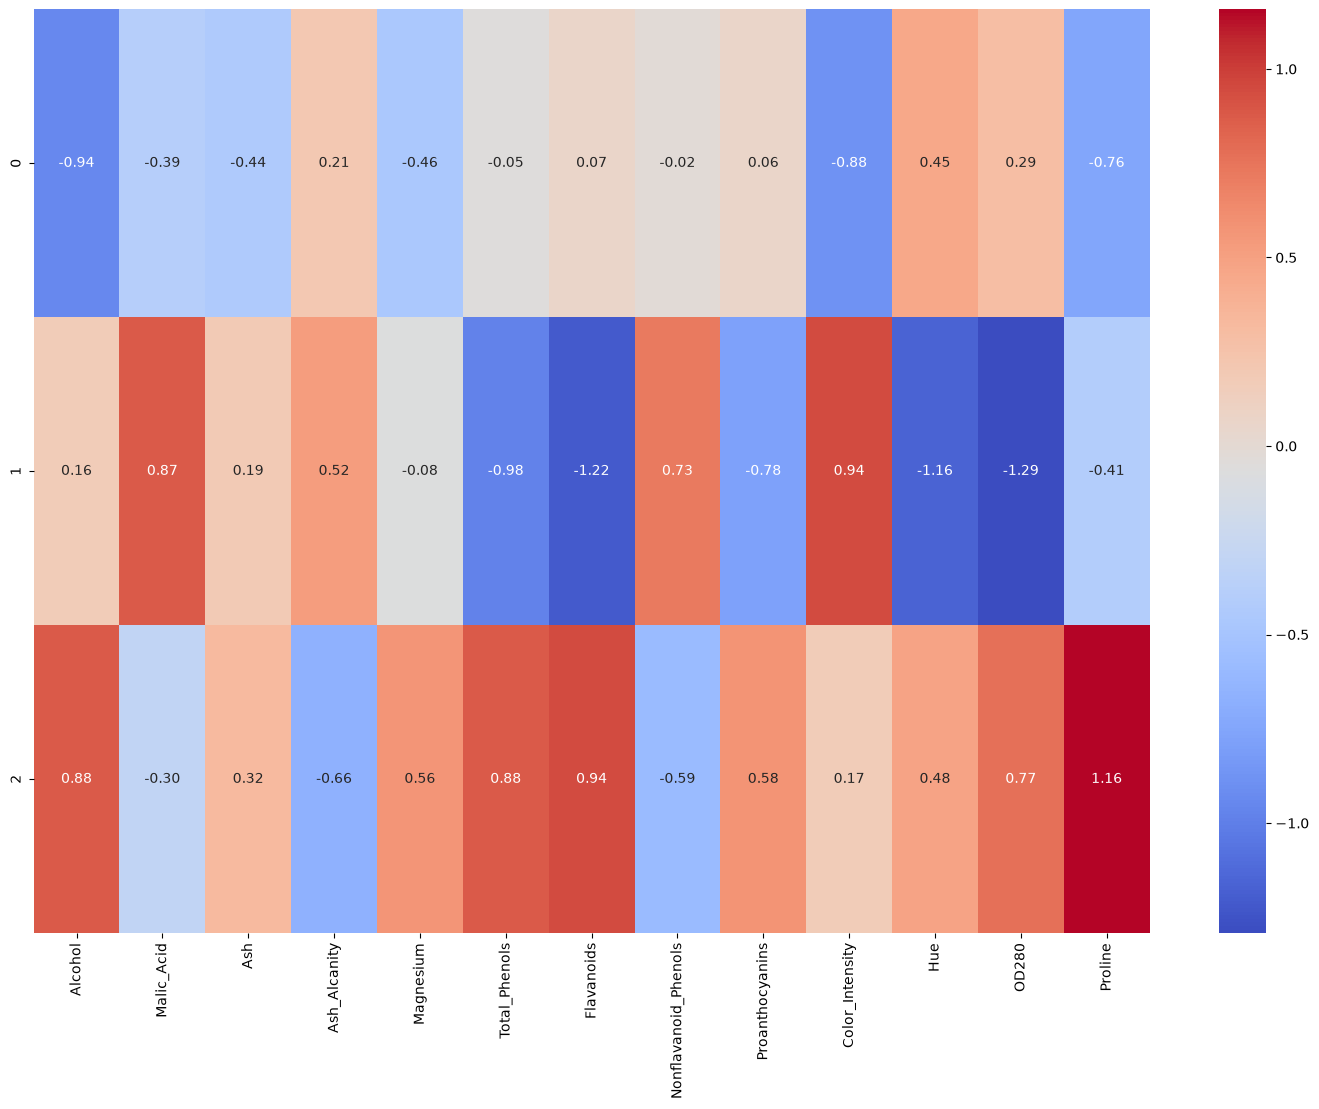

In [73]:
plt.figure(figsize=(18,12))
sns.heatmap(centers_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

----------------
## PCA Based Cluster Visualization

This section will use Principal Component Analysis (PCA) to reduce the 13 standardized features into two principal components. These components will be used to visualize the K-Means clusters in two dimensions and assess how clearly the three groups are separated.

In [74]:
from sklearn.decomposition import PCA

In [75]:
pca = PCA(n_components=2)

In [76]:
pca_data = pca.fit_transform(data_exp1)

In [80]:
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Clusters'] = model.labels_

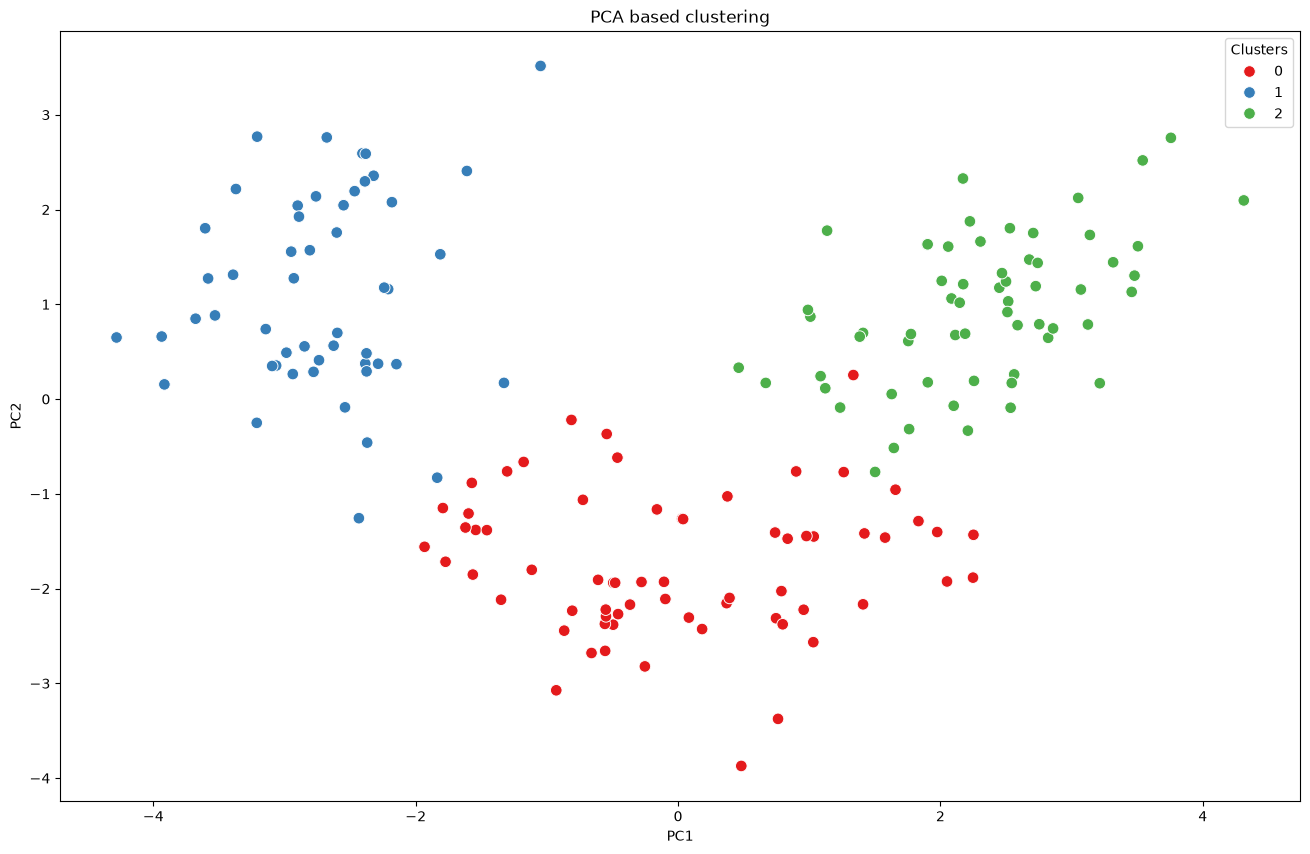

In [86]:
plt.figure(figsize=(16,10))
sns.scatterplot(data=pca_df, x="PC1", y='PC2', hue='Clusters', palette="Set1", s=70)
plt.title("PCA based clustering")
plt.show()

### PCA Visualization Evaluation

The PCA visualization shows three recognizable cluster regions with limited overlap. Although the silhouette score indicates only moderate separation, the clusters still appear meaningfully structured in the 2D projection, suggesting that K-Means captured useful grouping patterns in the standardized data.

-----------
## PCA Explained Variance

This section will examine how much of the original dataset’s variation is captured by the first two principal components. This helps determine how much information is represented in the 2D PCA visualization and how confidently the cluster plot can be interpreted.

In [87]:
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 ])

In [88]:
pca.explained_variance_ratio_.sum()

np.float64(0.5540633835693527)

----------------
## Experiment 1 Conclusion

The first K-Means experiment produced three reasonably balanced and distinct clusters. The Elbow Method and Silhouette Score supported `k = 3`, while centroid analysis showed clear differences in feature profiles across the clusters. PCA visualization also showed visible separation, although the first two components captured only about 55% of the total variance.

Overall, the baseline clustering is promising, but the moderate silhouette score suggests that alternative preprocessing methods may be worth testing in a second experiment.